In [1]:
from gammaraytoys.detectors import ToyCodedMaskDetector3D
import matplotlib.pyplot as plt
import numpy as np
import astropy.units as u
from astropy.coordinates import Angle, SkyCoord, UnitSphericalRepresentation
from astropy.units import Quantity
from scipy.stats import poisson, norm, chi2
from histpy import Histogram, Axis

from gammaraytoys import poisson_binned_log_likelihood, unbinned_log_likelihood, richardson_lucy

In [5]:
det = ToyCodedMaskDetector3D.create_random_mask(mask_size = 40 * u.cm, 
                                                mask_npix = 13, 
                                                mask_separation = 100 * u.cm, 
                                                open_fraction = .5, 
                                                detector_size = 22 * u.cm, 
                                                detector_npix = 44, 
                                                detector_efficiency = 0.65)

(<Axes: xlabel='x [cm]', ylabel='y [cm]'>,
 <matplotlib.collections.QuadMesh at 0x12ab80810>)

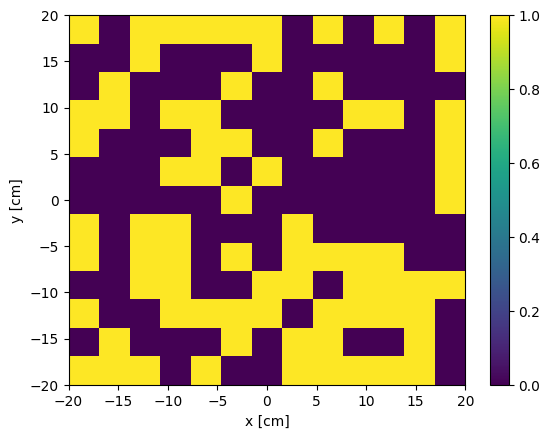

In [6]:
det.mask.plot()

100%|██████████| 44/44 [00:00<00:00, 72.30it/s]


(<Axes: xlabel='x [cm]', ylabel='y [cm]'>,
 <matplotlib.collections.QuadMesh at 0x12acdedd0>)

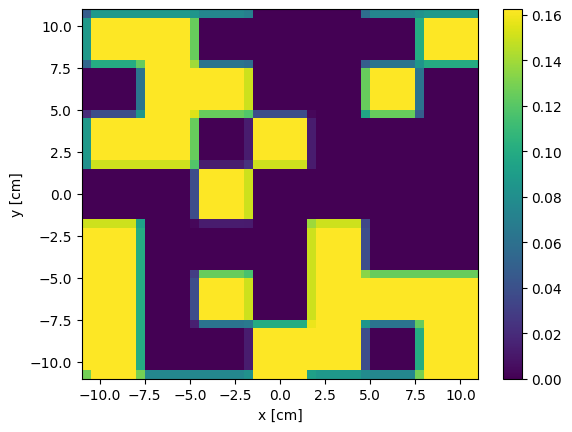

In [8]:
coord = SkyCoord(l = 0*u.deg, b = 0*u.deg, frame = 'galactic')

shadowgram = det.point_source_response(1/u.cm/u.cm/u.s, 1*u.s, coord)

shadowgram.plot()

In [11]:
import cProfile

%load_ext line_profiler

In [10]:
cProfile.run('det.point_source_response(1/u.cm/u.cm/u.s, 1*u.s, coord)', filename = "psr.prof")

100%|██████████| 44/44 [00:01<00:00, 27.06it/s]


In [13]:
%lprun -f det.point_source_response.__wrapped__ det.point_source_response(1/u.cm/u.cm/u.s, 1*u.s, coord)

100%|██████████| 44/44 [00:01<00:00, 30.40it/s]


Timer unit: 1e-09 s

Total time: 1.44012 s
File: /Users/imartin5/software/gammaraytoys/gammaraytoys/detectors/coded_mask/threeD/coded_mask_3d.py
Function: point_source_response at line 147

Line #      Hits         Time  Per Hit   % Time  Line Contents
   147                                               @u.quantity_input(flux = u.Unit()/u.m/u.m/u.s, duration = u.s, angle = u.rad)
   148                                               def point_source_response(self, flux, duration, coord, fluctuate = False):
   149                                           
   150                                                   # Standarize coordinate
   151         1      58000.0  58000.0      0.0          coord = coord.represent_as(UnitSphericalRepresentation)
   152                                           
   153         1      41000.0  41000.0      0.0          lon = coord.lon.to_value(u.rad)
   154         1      14000.0  14000.0      0.0          lat = coord.lat.to_value(u.rad)
   155          

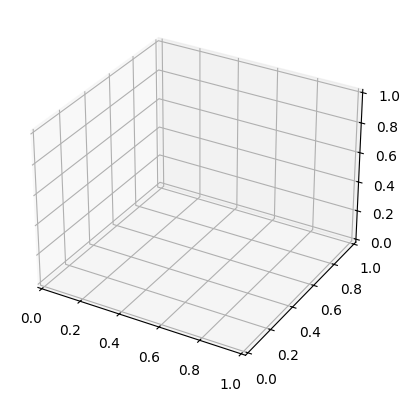

In [9]:
fig,ax = plt.subplots(subplot_kw={'projection':'3d'})

ax.plot_surface

In [55]:
[[]]*10

[[], [], [], [], [], [], [], [], [], []]

In [51]:
a = np.full(10, tuple([]), dtype = object)

ValueError: could not broadcast input array from shape (0,) into shape (10,)

In [38]:
for mask_i, geom_weight in [[1, .5]]:
    print(mask_i, geom_weight)

1 0.5


In [45]:
a[0] = tuple([[1, .5]])

In [46]:
a

array([([1, 0.5],), 0, 0, 0, 0, 0, 0, 0, 0, 0], dtype=object)

In [56]:
x = [3,4,5]
x += [5,6]

In [57]:
x

[3, 4, 5, 5, 6]